Project question:
How has the spatial extent (footprint area, km²) of photovoltaic installations in the Talatan Solar Park (Gonghe County, Qinghai, China) changed between 2016 and 2026, as measured by object/semantic detection on satellite imagery? 

Study area:
Talatan PV base, Gonghe County, China: Approx. bounding box around 35.94–36.3°N, 100.05–100.67°E.

Time period:
2016-2026

Main raster dataset: Sentinel-2 Level-2A
Provider: ESA, accessed through Microsoft Planetary Computer
Access route: Planetary Computer STAC API
Search criteria:
Useful assets or bands: Blue/Green/Red/NIR
Expected output: Interactive Slider map showing the PV installations as detected polygones over the years.
Main limitation: The detection model may confuse PV panels with other dark surfaces (e.g. shadows, wet soil, asphalt), or fail to detect different types of PV installations.

Main vector/context dataset:
Provider:
Access route:
Role in project:
Main limitation:

Small test:
What I tested:
What worked:
What did not work:
Next decision:

In [38]:
import sys
sys.path.append("../scripts")

from spatial_subsets import save_multiband_subset, plot_rgb

In [39]:
from pystac_client import Client
import planetary_computer as pc

pc_catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

talatan_bbox = [100.53, 36.09, 100.51, 36.10]  # WGS84 lon/lat around Talatan

search = pc_catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=talatan_bbox,
    datetime="2026-06-01/2026-08-31",
    query={"eo:cloud_cover": {"lt": 20}},
    max_items=10,
)

items = list(search.items())
print(f"Found {len(items)} Sentinel-2 item(s)")

Found 10 Sentinel-2 item(s)


Select the least-cloudy item and inspect its assets.

In [40]:
items_sorted = sorted(
    items,
    key=lambda item: item.properties.get("eo:cloud_cover", 999),
)

s2_item = pc.sign(items_sorted[0])

print("Selected item:", s2_item.id)
print("Date:", s2_item.datetime)
print("Cloud cover:", round(s2_item.properties.get("eo:cloud_cover"), 2))

print("\nUseful assets:")
for key in ["B02", "B03", "B04", "B08", "SCL", "visual"]:
    if key in s2_item.assets:
        print(key, "-", s2_item.assets[key].title)

Selected item: S2B_MSIL2A_20260819T035529_R004_T47SPV_20260819T055611
Date: 2026-08-19 03:55:29.024000+00:00
Cloud cover: 2.47

Useful assets:
B02 - Band 2 - Blue - 10m
B03 - Band 3 - Green - 10m
B04 - Band 4 - Red - 10m
B08 - Band 8 - NIR - 10m
SCL - Scene classfication map (SCL)
visual - True color image


Download only a small RGB subset.



Saved: data/raw/rasters2_talatan_rgb_subset.tif (0.09 MB)


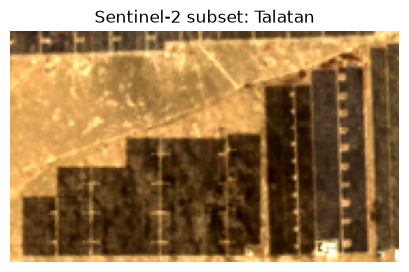

In [43]:
from matplotlib_scalebar.scalebar import ScaleBar
s2_subset = save_multiband_subset(
    item=s2_item,
    asset_keys=["B04", "B03", "B02"],  # red, green, blue
    bbox_wgs84=talatan_bbox,
    output_path="data/raw/rasters2_talatan_rgb_subset.tif",
)

plot_rgb(s2_subset, "Sentinel-2 subset: Talatan")